GRUPO N°9

# ***Predicción de la dirección del S&P 500 mediante Machine Learning***

**Descripción del proyecto**

Este proyecto tiene como objetivo desarrollar y evaluar modelos de Machine Learning para predecir la dirección futura del índice S&P 500 utilizando datos históricos del mercado e indicadores técnicos.

A lo largo del trabajo se realizaron distintos experimentos con diferentes algoritmos, conjuntos de variables y frecuencias temporales con el fin de analizar su impacto en la capacidad predictiva del modelo.

---

**Tipo de problema**

Se plantea un problema de **clasificación binaria**, donde:

- **1:** el precio de cierre del S&P 500 sube en la siguiente VELA DE H1.
- **0:** el precio de cierre del S&P 500 baja o permanece sin cambios EN LA SIGUIENTE VELA DE H1.

---

**Dataset**

**Fuente:** Yahoo Finance

**Activo principal:** S&P 500 (`^GSPC`)

**Período analizado:** 2005 - 2024

**Frecuencia utilizada:**

- Datos horarios (primeros experimentos).
- Datos diarios (modelo final).

Además, se incorporaron variables externas provenientes de:

- Índice de volatilidad VIX (`^VIX`)
- Bono del Tesoro de EE.UU. a 10 años (`^TNX`)
- Índice dólar (DXY)
- Futuros del Oro (`GC=F`)

---

**Ingeniería de características**

Se construyeron variables derivadas para capturar distintos aspectos del mercado, entre ellas:

- Retornos acumulados.
- Volatilidad histórica.
- Volumen normalizado.
- Distancia respecto a medias móviles exponenciales.
- RSI.
- MACD.
- Bandas de Bollinger.
- Variables temporales.
- Variables macroeconómicas.
- Correlaciones entre activos.

En total se utilizaron **38 variables predictoras**.

---

**Modelos evaluados**

Durante el desarrollo del proyecto se implementaron y compararon los siguientes modelos:

- Random Forest.
- Random Forest optimizado mediante Randomized Search CV.
- Random Forest optimizado mediante Grid Search CV.
- XGBoost.
- LightGBM.

La validación se realizó utilizando **TimeSeriesSplit** y **Walk-Forward Validation**, respetando el orden cronológico de los datos.

---

**Métricas de evaluación**

Para evaluar el desempeño de los modelos se utilizaron las siguientes métricas:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- AUC-ROC.
- Matriz de confusión.

---

**Resultados**

La incorporación de nuevas variables técnicas y externas permitió obtener mejoras moderadas respecto a los modelos iniciales.

Sin embargo, incluso utilizando algoritmos avanzados como LightGBM y XGBoost, junto con optimización de hiperparámetros y validación temporal, la capacidad predictiva permaneció limitada, alcanzando valores cercanos a:

- **Accuracy:** ~53%
- **AUC-ROC:** ~52%

Estos resultados reflejan la dificultad inherente de predecir la dirección futura del mercado utilizando únicamente información histórica.

---

**Principales conclusiones**

- La ingeniería de características tuvo un impacto mayor que la optimización de hiperparámetros.
- El cambio de datos horarios a datos diarios produjo mejoras leves pero no sustanciales.
- Modelos más complejos no lograron superar ampliamente el desempeño de Random Forest.
- La validación temporal confirmó que las señales predictivas encontradas no son consistentes a lo largo del tiempo.

---

**Tecnologías utilizadas**

- Python
- Pandas
- NumPy
- Scikit-learn
- LightGBM
- XGBoost
- yfinance
- Matplotlib
- Seaborn

---

**Aviso**

Este proyecto tiene fines exclusivamente educativos y de investigación.

Los modelos desarrollados **no constituyen recomendaciones de inversión** ni garantizan rentabilidad en mercados financieros.

# Modelado predictivo del S&P 500 con Machine Learning

En este notebook se desarrolla una primera versión funcional del núcleo técnico del sistema.
El objetivo es entrenar un modelo de Machine Learning supervisado para predecir si el precio de cierre del S&P 500 subirá o bajará en la siguiente vela horaria.

El problema se plantea como una tarea de clasificación binaria:

- 1: el precio sube en la siguiente hora VELA DE H1.
- 0: el precio no sube o baja en la siguiente hora VELA DE H1.

Esta versión no busca garantizar rentabilidad financiera, sino demostrar un pipeline técnico funcional de carga de datos, preprocesamiento, entrenamiento, predicción y evaluación.

## ETL

### Importación de Librerias

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

### Descarga de Datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/cs de datos data set/SP500_2_anios_h1.csv', skiprows=[1, 2])

df.head()

,Price,Close,High,Low,Open,Volume
0,2024-04-11 13:30:00+00:00,5143.169922,5176.140137,5138.770020,5172.950195,0
1,2024-04-11 14:30:00+00:00,5152.750000,5158.680176,5141.990234,5143.149902,246598771
2,2024-04-11 15:30:00+00:00,5165.939941,5172.439941,5151.959961,5152.750000,201089760
3,2024-04-11 16:30:00+00:00,5192.520020,5195.729980,5164.979980,5165.990234,201419150
4,2024-04-11 17:30:00+00:00,5207.830078,5209.500000,5187.689941,5192.609863,220782000


### Exploración y Limpieza de Datos

In [ ]:
# Verificar nombres de columnas
print(df.columns)

# Si la columna de fecha viene como 'Price', la renombramos a 'Datetime'
if 'Price' in df.columns:
    df = df.rename(columns={'Price': 'Datetime'})

# Si la fecha ya quedó como índice, la recuperamos como columna
if 'Datetime' not in df.columns and df.index.name == 'Datetime':
    df = df.reset_index()

# Limpiar y preparar columna de fecha
df = df.dropna(subset=['Datetime'])
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Ordenar temporalmente y usar Datetime como índice
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)

df.head()

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-04-11 13:30:00+00:00,5143.169922,5176.140137,5138.770020,5172.950195,0
2024-04-11 14:30:00+00:00,5152.750000,5158.680176,5141.990234,5143.149902,246598771
2024-04-11 15:30:00+00:00,5165.939941,5172.439941,5151.959961,5152.750000,201089760
2024-04-11 16:30:00+00:00,5192.520020,5195.729980,5164.979980,5165.990234,201419150
2024-04-11 17:30:00+00:00,5207.830078,5209.500000,5187.689941,5192.609863,220782000


In [ ]:
df.info()

print("\nValores nulos por columna:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3483 entries, 2024-04-11 13:30:00+00:00 to 2026-04-10 19:30:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3483 non-null   float64
 1   High    3483 non-null   float64
 2   Low     3483 non-null   float64
 3   Open    3483 non-null   float64
 4   Volume  3483 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 163.3 KB

Valores nulos por columna:


,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
# Eliminación de Nulos si los hay
df = df.dropna()

In [ ]:
# Columnas Numéricas (Asegurarse que sean del tipo correcto)
cols_numericas = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3483 entries, 2024-04-11 13:30:00+00:00 to 2026-04-10 19:30:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3483 non-null   float64
 1   High    3483 non-null   float64
 2   Low     3483 non-null   float64
 3   Open    3483 non-null   float64
 4   Volume  3483 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 163.3 KB


## Features Engineering

No conviene usar solo Open, High, Low, Close, Volume. Es mejor crear variables derivadas.

Features recomendadas:
Estas features son defendibles porque salen de los precios históricos y ayudan a representar momentum, volatilidad y comportamiento de la vela.

In [ ]:
df['return_1h'] = df['Close'].pct_change()
df['return_3h'] = df['Close'].pct_change(3)
df['return_6h'] = df['Close'].pct_change(6)

df['range'] = df['High'] - df['Low']
df['body'] = abs(df['Close'] - df['Open'])

df['ema_10'] = df['Close'].ewm(span=10, adjust=False).mean()
df['ema_20'] = df['Close'].ewm(span=20, adjust=False).mean()

df['volatility_10'] = df['return_1h'].rolling(window=10).std()

df = df.dropna()

## Variable Objetivo

Esta parte es clave.

El target tiene que mirar el cierre futuro:
Si el cierre de la próxima vela es mayor al cierre actual → 1
Si no → 0
Esto convierte el problema en clasificación binaria.

In [ ]:
df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna()

## Seleccion de Features

In [ ]:
features = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'return_1h', 'return_3h', 'return_6h',
    'range', 'body',
    'ema_10', 'ema_20',
    'volatility_10'
]

X = df[features]
y = df['target']

## Split Temporal
Dividir train/test respetando el tiempo

Este punto es importante. En series temporales no conviene mezclar aleatoriamente los datos.
Esto significa:

Primer 80% del tiempo: entrenamiento.
Último 20% del tiempo: prueba.

Es más correcto para datos financieros porque simula mejor el uso real del modelo.

In [ ]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


print(f"Train: {len(X_train):,} muestras  ({X_train.index[0]} → {X_train.index[-1]})")
print(f"Test : {len(X_test):,}  muestras  ({X_test.index[0]} → {X_test.index[-1]})")


Train: 2,778 muestras  (2024-04-12 16:30:00+00:00 → 2025-11-13 17:30:00+00:00)
Test : 695  muestras  (2025-11-13 18:30:00+00:00 → 2026-04-10 19:30:00+00:00)


## Random Forest

### Entrenamiento

Para esta entrega, usá Random Forest. Es más simple de defender que XGBoost y no requiere tanta configuración.
Se eligió Random Forest porque es un modelo adecuado para datos tabulares, permite capturar relaciones no lineales y es robusto frente al ruido. Además, funciona bien como primera aproximación sin requerir una arquitectura compleja.

In [ ]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    class_weight='balanced'
)

modelo.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

### Predicciones

In [ ]:
y_pred = modelo.predict(X_test)

y_pred[:10]

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0])

También podés obtener probabilidades:
Eso te sirve para decir que el modelo no solo predice 0 o 1, sino que también puede entregar una probabilidad estimada.

In [ ]:
y_proba = modelo.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.47494243, 0.48093063, 0.53960437, 0.4658686 , 0.51759322,
       0.46163826, 0.45985471, 0.46261506, 0.46603299, 0.49814681])

### Evaluacion del modelo

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.4935251798561151
Precision: 0.5174129353233831
Recall: 0.28969359331476324
F1-score: 0.37142857142857144


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.71      0.58       336
           1       0.52      0.29      0.37       359

    accuracy                           0.49       695
   macro avg       0.50      0.50      0.47       695
weighted avg       0.50      0.49      0.47       695



Explicación de Métricas del Modelo

🔹 Accuracy

El **Accuracy** representa el porcentaje total de predicciones correctas realizadas por el modelo sobre el total de casos evaluados.

Interpretación

Un accuracy de **0.49** indica que el modelo acertó aproximadamente el **49%** de las predicciones.

Esto sugiere que el modelo todavía presenta dificultades para distinguir correctamente entre ambas clases. En problemas financieros o bursátiles esto puede ocurrir debido a:

- Alta volatilidad del mercado
- Ruido en los datos
- Comportamientos no lineales
- Factores externos difíciles de modelar

Por esta razón, el accuracy no debe analizarse de forma aislada.

---

🔹 Precision

La **Precision** mide qué proporción de las predicciones positivas realizadas por el modelo fueron realmente correctas.

Interpretación

Una precision de **0.52** indica que cuando el modelo predice la clase positiva, acierta aproximadamente el **52%** de las veces.

Esto significa que:

- El modelo tiene una capacidad moderada para detectar señales positivas.
- Existen falsos positivos.
- Algunas predicciones de subida del mercado pueden ser incorrectas.

En trading, esta métrica es importante porque ayuda a evaluar la confiabilidad de las señales generadas.

---

🔹 Recall

El **Recall** mide la capacidad del modelo para detectar correctamente todos los casos positivos reales.

Interpretación

Un recall de **0.29** significa que el modelo detecta solamente el **29%** de los casos positivos reales.

Esto indica que:

- El modelo pierde muchas oportunidades positivas.
- Existen numerosos falsos negativos.
- El modelo es conservador al predecir la clase positiva.

En términos prácticos, el modelo no logra anticipar muchos movimientos reales del mercado.

---

🔹 F1-Score

El **F1-Score** combina Precision y Recall en una única métrica de equilibrio.

Interpretación

Un F1-score de **0.37** indica que todavía no existe un buen equilibrio entre:

- Detectar correctamente los casos positivos
- Evitar errores en las predicciones

Un valor bajo de F1-score suele reflejar:

- Problemas de generalización
- Desbalance entre precision y recall
- Necesidad de mejorar variables o hiperparámetros

Esta métrica es especialmente útil cuando el dataset posee clases desbalanceadas.

---
📋 **Classification Report**

El **Classification Report** resume el rendimiento del modelo para cada clase individualmente utilizando las métricas:

- Precision
- Recall
- F1-Score
- Support

Permite analizar cómo se comporta el modelo tanto para la clase 0 como para la clase 1.

**Interpretación**

En los resultados obtenidos, el modelo presenta un mejor desempeño en la predicción de la clase 0, mientras que muestra mayores dificultades para detectar correctamente la clase 1.

Esto se observa principalmente en el valor bajo de recall para la clase positiva, indicando que el modelo pierde varios casos reales positivos.

El classification report resulta útil para identificar desequilibrios y comprender con mayor detalle las fortalezas y debilidades del modelo.

### Confusion Matrix

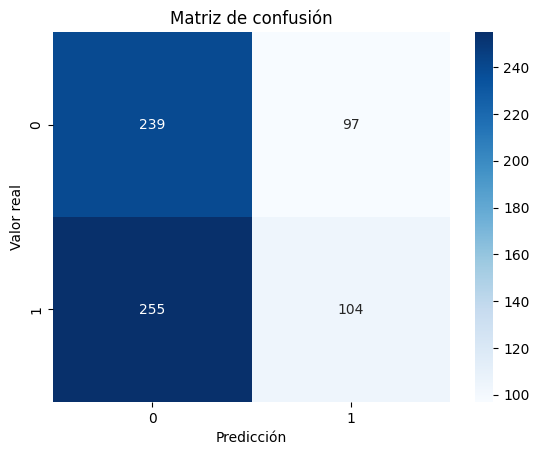

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión')
plt.show()

📊 **Interpretación de la Matriz de Confusión**

La matriz de confusión obtenida muestra el comportamiento real del modelo al momento de clasificar las observaciones.

|                | Predicción 0 | Predicción 1 |
|----------------|--------------|--------------|
| Valor real 0   | 239          | 97           |
| Valor real 1   | 255          | 104          |

**Interpretación de los resultados**

- **239 Verdaderos Negativos (TN):**  
El modelo predijo correctamente la clase 0.

- **104 Verdaderos Positivos (TP):**  
El modelo logró identificar correctamente algunos casos positivos.

- **97 Falsos Positivos (FP):**  
El modelo predijo la clase positiva cuando en realidad era negativa.

- **255 Falsos Negativos (FN):**  
El modelo no logró detectar muchos casos positivos reales.

**Conclusión**

El principal problema del modelo se encuentra en la gran cantidad de falsos negativos, lo que explica el recall bajo obtenido anteriormente.

Esto indica que el modelo tiene dificultades para detectar correctamente la clase positiva y tiende a predecir con mayor frecuencia la clase 0.

En un contexto financiero, esto significa que el modelo podría perder oportunidades reales de movimientos positivos del mercado.

### Importancia de variables



In [ ]:
importancias = pd.DataFrame({
    'feature': features,
    'importance': modelo.feature_importances_
}).sort_values(by='importance', ascending=False)

importancias

,feature,importance
12,volatility_10,0.111746
7,return_6h,0.106934
9,body,0.101690
6,return_3h,0.084604
5,return_1h,0.081281
8,range,0.080529
4,Volume,0.075022
2,Low,0.066238
10,ema_10,0.064014
3,Close,0.060377


El modelo asignó mayor importancia a determinadas variables relacionadas con precio, retorno y volatilidad.

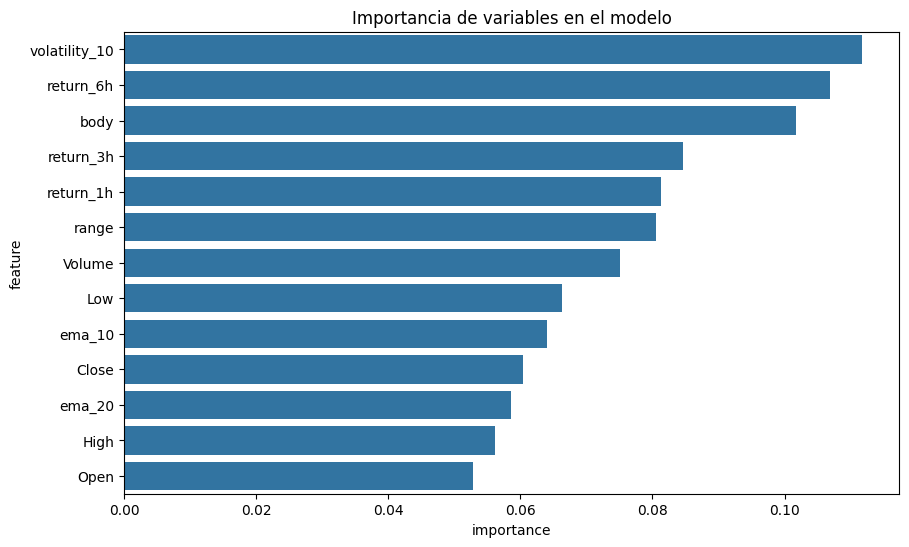

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias, x='importance', y='feature')
plt.title('Importancia de variables en el modelo')
plt.show()

📊 **Importancia de Variables**

La importancia de variables permite identificar cuáles son las características que más influyen en las predicciones del modelo.

Las variables con mayor importancia son aquellas que aportan más información para diferenciar entre las clases y ayudan al modelo a tomar decisiones más precisas.

**Interpretación**

El análisis de importancia de variables resulta fundamental porque permite:

- Comprender cómo toma decisiones el modelo.
- Detectar variables relevantes.
- Eliminar variables poco útiles.
- Mejorar el rendimiento del modelo mediante feature engineering.

Además, ayuda a interpretar el comportamiento del modelo y entender qué factores tienen mayor impacto en la predicción final.

### RandomizedSearchCV

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)  #para series temporales

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

modelo = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

parametros = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=modelo,
    param_distributions=parametros,
    n_iter=20,
    cv=tscv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='accuracy')

In [ ]:
print(random_search.best_params_)
print(random_search.best_score_)
best_model = random_search.best_estimator_

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
0.5140388768898487


In [ ]:
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.61      0.53       336
           1       0.49      0.35      0.41       359

    accuracy                           0.48       695
   macro avg       0.48      0.48      0.47       695
weighted avg       0.48      0.48      0.47       695



### Análisis de los resultados

La optimización de hiperparámetros mediante Randomized Search CV produjo cambios mixtos en el desempeño del modelo. Si bien la exactitud general (Accuracy) disminuyó ligeramente de 49,4% a 47,9%, se observó una mejora en la capacidad del modelo para identificar correctamente la clase positiva.

El Recall de la clase 1 aumentó de 0,29 a 0,35, lo que indica que el modelo logró detectar una mayor proporción de los casos positivos. Asimismo, el F1-Score pasó de 0,37 a 0,41, reflejando un mejor equilibrio entre precisión y cobertura para dicha clase.

Por otro lado, la Precision disminuyó levemente de 0,52 a 0,49 y el desempeño sobre la clase 0 también se redujo, evidenciando un intercambio entre la detección de ambas clases.

En términos generales, aunque el modelo optimizado no mejoró la Accuracy global, sí consiguió una mejor capacidad para reconocer la clase positiva, lo cual se refleja principalmente en el incremento del Recall y del F1-Score. Dado que el objetivo del problema consiste en predecir correctamente la dirección futura del mercado, esta mejora puede considerarse relevante y justificar la utilización de los hiperparámetros encontrados por Randomized Search CV.

In [ ]:
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    max_features='sqrt',
    random_state=42
)

modelo.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, random_state=42)

In [ ]:
y_pred = modelo.predict(X_test)

y_pred[:10]

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1])

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.4920863309352518
Precision: 0.5113636363636364
Recall: 0.37604456824512533
F1-score: 0.4333868378812199


## Modelo XGBoost

XGBoost aplica boosting secuencial: cada árbol corrige los errores del anterior.
Suele superar a Random Forest en datasets tabulares con features bien construidas.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

xgb_model = XGBClassifier(
    n_estimators  = 300,
    max_depth      = 5,
    learning_rate  = 0.05,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    eval_metric    = "logloss",
    random_state   = 42,
    verbosity      = 0
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost — Accuracy: {xgb_acc:.4f}  |  AUC-ROC: {xgb_auc:.4f}")
print()
print(classification_report(y_test, xgb_preds, target_names=["Baja (0)", "Sube (1)"]))

XGBoost — Accuracy: 0.4863  |  AUC-ROC: 0.4776

              precision    recall  f1-score   support

    Baja (0)       0.47      0.54      0.51       336
    Sube (1)       0.50      0.43      0.46       359

    accuracy                           0.49       695
   macro avg       0.49      0.49      0.49       695
weighted avg       0.49      0.49      0.48       695



El modelo XGBoost alcanzó una Accuracy de 48,6% y un AUC-ROC de 47,8% sobre el conjunto de prueba. Para la clase positiva ("Sube"), obtuvo una Precision de 50%, un Recall de 42,9% y un F1-Score de 46,1%. Si bien la exactitud general se mantuvo en valores similares a los modelos Random Forest, XGBoost logró una mejor capacidad para identificar movimientos alcistas del mercado, reflejada en los mayores valores de Recall y F1-Score para la clase positiva.

### Análisis
**Random Forest Base**

El modelo inicial obtuvo una Accuracy cercana al 49%, pero presentó dificultades para identificar correctamente los movimientos alcistas del mercado. Esto se refleja en un Recall de apenas 29% para la clase "Sube", indicando que la mayoría de las subidas reales no fueron detectadas por el modelo.

**Random Forest Optimizado**

La aplicación de Randomized Search CV permitió encontrar una mejor combinación de hiperparámetros. Aunque la Accuracy disminuyó ligeramente, el Recall aumentó de 29% a 35% y el F1-Score de la clase positiva pasó de 0.37 a 0.41. Esto indica una mejora en la detección de señales alcistas.

**XGBoost**

El modelo XGBoost obtuvo una Accuracy similar a los modelos anteriores (48.6%), pero logró el mejor desempeño sobre la clase positiva:

Recall: 42.9%
F1-Score: 46.1%

Esto significa que identificó una mayor cantidad de movimientos alcistas reales que los modelos de Random Forest.

Sin embargo, el valor de AUC-ROC fue de 0.478, inferior a 0.50. Esto indica que el modelo posee una capacidad discriminatoria limitada para separar correctamente ambas clases utilizando las probabilidades predichas.

## Conclusión

En esta entrega se desarrolló una primera versión funcional del sistema de predicción de movimientos del índice S&P 500 utilizando técnicas de Machine Learning. Se realizó la carga y preprocesamiento de datos históricos, la generación de variables predictoras y la construcción de un target binario para representar la dirección futura del mercado.

Posteriormente, se entrenó un modelo base de Random Forest, el cual fue evaluado mediante métricas de clasificación como Accuracy, Precision, Recall y F1-Score. Con el objetivo de mejorar su desempeño, se aplicó un proceso de optimización de hiperparámetros utilizando Randomized Search CV, obteniéndose mejoras en la capacidad del modelo para detectar la clase positiva.

Finalmente, se implementó un modelo XGBoost para comparar resultados. Aunque la Accuracy de los distintos modelos se mantuvo cercana al 50%, XGBoost logró los mejores valores de Recall (42,9%) y F1-Score (46,1%) para la clase positiva, mostrando una mayor capacidad para identificar movimientos alcistas del mercado en comparación con los modelos Random Forest.

Los resultados obtenidos evidencian la complejidad inherente a la predicción de mercados financieros, donde incluso modelos avanzados presentan dificultades para superar significativamente el desempeño aleatorio. Sin embargo, el proyecto permitió construir un pipeline completo de Machine Learning, incorporando preprocesamiento, validación temporal, optimización de hiperparámetros y comparación de algoritmos, sentando una base sólida para futuras mejoras mediante nuevas variables, indicadores técnicos y técnicas más avanzadas de modelado.


## Justificación de decisiones técnicas

El problema se planteó como una tarea de clasificación binaria, donde el objetivo es predecir si el precio del S&P 500 subirá o bajará en la siguiente vela horaria. Para ello, se utilizaron variables históricas del mercado y features derivadas obtenidas durante el preprocesamiento.

Se seleccionó inicialmente Random Forest por su capacidad para trabajar con datos tabulares, capturar relaciones no lineales y ofrecer una implementación robusta y fácilmente interpretable. Posteriormente, se aplicó Randomized Search CV para optimizar sus hiperparámetros y mejorar su desempeño.

Además, se incorporó XGBoost como modelo alternativo para comparar resultados. Este algoritmo permitió obtener mejores métricas de Recall y F1-Score para la clase positiva, mostrando una mayor capacidad para detectar movimientos alcistas del mercado.

La evaluación de los modelos se realizó mediante Accuracy, Precision, Recall, F1-Score y AUC-ROC, métricas adecuadas para medir el desempeño en problemas de clasificación binaria.


# Nuevas Features (Incorporacion de Nuevas Variables Predictoras)


Los resultados obtenidos con el conjunto inicial de variables mostraron una capacidad predictiva limitada, incluso después de aplicar técnicas de optimización de hiperparámetros. Por este motivo, se decidió realizar una nueva etapa de ingeniería de características, incorporando indicadores técnicos y variables derivadas ampliamente utilizadas en el análisis financiero.

El objetivo fue proporcionar al modelo información más relevante sobre tendencia, momentum, volatilidad y comportamiento del precio, con la expectativa de mejorar su capacidad para identificar patrones asociados a futuros movimientos del mercado.


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

## Feature Engineering

Se construyen indicadores técnicos ampliamente utilizados en análisis cuantitativo:

| Feature | Descripción |
|---|---|
| `return_1h/3h/6h` | Retornos porcentuales rezagados |
| `volatility` | Rango High-Low por vela |
| `volume_norm` | Volumen normalizado por media 20 periodos |
| `dist_ema10/20` | Distancia relativa a EMA 10 y 20 |
| `ema_cross` | Señal de cruce EMA 10 > EMA 20 |
| `momentum` | Cambio absoluto de precio en 5 periodos |
| `rsi` | Relative Strength Index (14 periodos) |
| `macd` | MACD = EMA12 − EMA26 |
| `macd_signal` | Línea de señal del MACD (EMA9 del MACD) |
| `bb_width` | Ancho de Bandas de Bollinger (volatilidad relativa) |
| `bb_position` | Posición del precio dentro de las Bandas |


In [ ]:
df.head()


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-04-11 13:30:00+00:00,5143.169922,5176.140137,5138.770020,5172.950195,0
2024-04-11 14:30:00+00:00,5152.750000,5158.680176,5141.990234,5143.149902,246598771
2024-04-11 15:30:00+00:00,5165.939941,5172.439941,5151.959961,5152.750000,201089760
2024-04-11 16:30:00+00:00,5192.520020,5195.729980,5164.979980,5165.990234,201419150
2024-04-11 17:30:00+00:00,5207.830078,5209.500000,5187.689941,5192.609863,220782000


In [ ]:
# ── Retornos ──────────────────────────────────────────────────────────────────
df["return_1h"] = df["Close"].pct_change()
df["return_3h"] = df["Close"].pct_change(3)
df["return_6h"] = df["Close"].pct_change(6)

# ── Volatilidad ───────────────────────────────────────────────────────────────
df["volatility"] = df["High"] - df["Low"]

# ── Volumen normalizado ───────────────────────────────────────────────────────
vol_ma = df["Volume"].rolling(20).mean()
df["volume_norm"] = df["Volume"] / vol_ma

# ── EMAs y distancias relativas ───────────────────────────────────────────────
df["ema_10"] = df["Close"].ewm(span=10).mean()
df["ema_20"] = df["Close"].ewm(span=20).mean()

df["dist_ema10"] = (df["Close"] - df["ema_10"]) / df["ema_10"]
df["dist_ema20"] = (df["Close"] - df["ema_20"]) / df["ema_20"]

df["ema_cross"] = (df["ema_10"] > df["ema_20"]).astype(int)

# ── Momentum ──────────────────────────────────────────────────────────────────
df["momentum"] = df["Close"] - df["Close"].shift(5)

# ── RSI (14) ──────────────────────────────────────────────────────────────────
delta = df["Close"].diff()
gain  = delta.where(delta > 0, 0).rolling(14).mean()
loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
df["rsi"] = 100 - (100 / (1 + gain / loss))

# ── MACD ──────────────────────────────────────────────────────────────────────
ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()
df["macd"]        = ema12 - ema26
df["macd_signal"] = df["macd"].ewm(span=9).mean()

# ── Bandas de Bollinger (20, 2σ) ──────────────────────────────────────────────
bb_mid   = df["Close"].rolling(20).mean()
bb_std   = df["Close"].rolling(20).std()
bb_upper = bb_mid + 2 * bb_std
bb_lower = bb_mid - 2 * bb_std

df["bb_width"]    = (bb_upper - bb_lower) / bb_mid        # volatilidad relativa
df["bb_position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)  # [0,1]

print("Features creadas. Nulos por columna:")
print(df.isnull().sum().to_string())


Features creadas. Nulos por columna:
Close           0
High            0
Low             0
Open            0
Volume          0
return_1h       1
return_3h       3
return_6h       6
volatility      0
volume_norm    19
ema_10          0
ema_20          0
dist_ema10      0
dist_ema20      0
ema_cross       0
momentum        5
rsi            13
macd            0
macd_signal     0
bb_width       19
bb_position    19


## Variable Objetivo
target = 1 si el precio de cierre de la siguiente hora es mayor al actual, 0 si baja.

Nota: Se aplica el shift antes de eliminar nulos para evitar data leakage en el borde del split train/test.

In [ ]:
# Creamos la columna Target
df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Eliminar filas con NaN (generadas por los indicadores y el shift del target)
df = df.dropna().reset_index(drop=True)

print(f"Dataset final: {len(df):,} registros")
print()
print("Distribución del target:")
print(df["target"].value_counts())
print()
balance = df["target"].value_counts(normalize=True) * 100
print(f"Sube: {balance[1]:.1f}%  |  Baja: {balance[0]:.1f}%")


Dataset final: 3,464 registros

Distribución del target:
target
1    1848
0    1616
Name: count, dtype: int64

Sube: 53.3%  |  Baja: 46.7%


## Selección de Features

In [ ]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'return_1h', 'return_3h',
       'return_6h', 'volatility', 'volume_norm', 'ema_10', 'ema_20',
       'dist_ema10', 'dist_ema20', 'ema_cross', 'momentum', 'rsi', 'macd',
       'macd_signal', 'bb_width', 'bb_position', 'target'],
      dtype='object')

In [ ]:
FEATURES = [
    "return_1h",
    "return_3h",
    "return_6h",
    "volatility",
    "volume_norm",
    "dist_ema10",
    "dist_ema20",
    "ema_cross",
    "momentum",
    "rsi",
    "macd",
    "macd_signal",
    "bb_width",
    "bb_position",
]

X = df[FEATURES]
y = df["target"]

print(f"Features: {len(FEATURES)}")
print(f"Muestras: {len(X):,}")

Features: 14
Muestras: 3,464


## Split Temporal

Se respeta el orden cronológico para evitar data leakage: el modelo nunca
entrena con datos futuros. El 80% inicial es entrenamiento y el 20% final es test.

In [ ]:
split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train):,} muestras  ({X_train.index[0]} → {X_train.index[-1]})")
print(f"Test : {len(X_test):,}  muestras  ({X_test.index[0]} → {X_test.index[-1]})")

Train: 2,771 muestras  (0 → 2770)
Test : 693  muestras  (2771 → 3463)


## Modelo Random Forest

Random Forest es un ensemble de árboles de decisión que promedia predicciones
para reducir la varianza. Es robusto al ruido y maneja bien features con
distintas escalas.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)


rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 8,
    min_samples_leaf = 20,
    random_state = 42,
    n_jobs       = -1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest — Accuracy: {rf_acc:.4f}  |  AUC-ROC: {rf_auc:.4f}")
print()
print(classification_report(y_test, rf_preds, target_names=["Baja (0)", "Sube (1)"]))


Random Forest — Accuracy: 0.5238  |  AUC-ROC: 0.5117

              precision    recall  f1-score   support

    Baja (0)       0.53      0.14      0.22       335
    Sube (1)       0.52      0.89      0.66       358

    accuracy                           0.52       693
   macro avg       0.53      0.51      0.44       693
weighted avg       0.53      0.52      0.45       693



La incorporación de nuevas variables e indicadores técnicos mejoró el desempeño del modelo respecto a las versiones anteriores. El Random Forest alcanzó una Accuracy de 52,4% y un AUC-ROC de 51,2%, obteniendo además un Recall de 88,8% para la clase "Sube".

Sin embargo, esta mejora estuvo acompañada por una baja capacidad para identificar la clase "Baja", cuyo Recall fue de solo 14,0%. Esto indica que el modelo presenta una tendencia a predecir movimientos alcistas con mayor frecuencia.

En general, los resultados sugieren que la ingeniería de características tuvo un impacto más importante en el desempeño del modelo que la optimización de hiperparámetros, aportando información más relevante para la predicción del mercado.



### Randomized Search CV

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

# Time Series Split
tscv = TimeSeriesSplit(n_splits=5)  #para series temporales

# Creación de Modelo
modelo = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)


# Parámetros
parametros = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 3, 5, 8, 10],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [4, 8, 16],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search CV
random_search = RandomizedSearchCV(
    estimator=modelo,
    param_distributions=parametros,
    n_iter=30,
    cv=tscv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

# Ajuste
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'max_depth': [None, 3, 5, 8, 10],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [4, 8, 16],
                                        'min_samples_split': [5, 10, 20],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc')

In [ ]:
# Mejores Parametros
print("\nMejores parámetros:")
print(random_search.best_params_)

# Mejor Score
print("\nMejor score CV:")
print(random_search.best_score_)

# Mejor Modelo y Entrenamiento
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)

# Predicciones
y_pred = best_model.predict(X_test)

# Evaluación Final
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))




Mejores parámetros:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 16, 'max_features': 'log2', 'max_depth': 3}

Mejor score CV:
0.4991252282764361

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.60      0.54       335
           1       0.53      0.42      0.47       358

    accuracy                           0.51       693
   macro avg       0.51      0.51      0.51       693
weighted avg       0.51      0.51      0.51       693



La optimización de hiperparámetros mediante Randomized Search CV permitió obtener un modelo más equilibrado entre ambas clases. Se alcanzó una Accuracy de 51,0%, con valores de Recall de 60,0% para la clase "Baja" y 42,0% para la clase "Sube".

Si bien el modelo perdió capacidad para detectar movimientos alcistas respecto al Random Forest configurado manualmente, logró una mejor distribución de las predicciones entre ambas clases. No obstante, el mejor AUC obtenido durante la validación cruzada fue de 0,499, valor muy cercano al comportamiento aleatorio, lo que sugiere que la capacidad predictiva del modelo sigue siendo limitada.

Estos resultados refuerzan la importancia de la selección y construcción de variables predictoras, ya que las mejoras en las features tuvieron un impacto mayor que la optimización de hiperparámetros sobre el desempeño final del modelo.


### Grid Search CV

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

# Validación temporal
tscv = TimeSeriesSplit(n_splits=5)

# Modelo base
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Grilla refinada
param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [8, 16, 24],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor AUC:")
print(grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores parámetros:
{'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'min_samples_split': 5, 'n_estimators': 300}

Mejor AUC:
0.5002515866800766


In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

print(classification_report(y_test, y_pred))

Accuracy: 0.5122655122655123
AUC: 0.5174268323188527
              precision    recall  f1-score   support

           0       0.50      0.59      0.54       335
           1       0.53      0.44      0.48       358

    accuracy                           0.51       693
   macro avg       0.52      0.51      0.51       693
weighted avg       0.52      0.51      0.51       693



La aplicación de Grid Search CV permitió explorar de manera exhaustiva distintas combinaciones de hiperparámetros para el modelo Random Forest. Los mejores parámetros obtenidos fueron `max_depth=3`, `min_samples_leaf=16`, `min_samples_split=5`, `n_estimators=300` y `max_features='sqrt'`.

El modelo alcanzó una Accuracy de 51,2% y un AUC-ROC de 51,7%, mostrando una ligera mejora respecto a los resultados obtenidos con Randomized Search CV. Sin embargo, las diferencias fueron reducidas, lo que indica que el ajuste de hiperparámetros tiene un impacto limitado sobre el desempeño del modelo.

En conjunto, los resultados sugieren que la principal fuente de mejora proviene de la incorporación de nuevas variables e indicadores técnicos, mientras que la optimización de hiperparámetros aporta beneficios más modestos. Esto resalta la importancia de la ingeniería de características en problemas de predicción financiera.


# Velas Diarias (Horizonte 1 dia - Cambio de Frecuencia Temporal)

Tras evaluar distintos modelos y conjuntos de variables sobre datos horarios, los resultados obtenidos mostraron una capacidad predictiva limitada. Por este motivo, se decidió modificar la frecuencia de análisis, pasando de velas horarias a velas diarias.

El objetivo de este cambio es reducir el ruido presente en los movimientos intradía y permitir que el modelo capture patrones de tendencia más estables. En esta nueva etapa, el problema se plantea como una clasificación binaria cuyo objetivo es predecir si el índice S&P 500 cerrará al alza o a la baja en la siguiente jornada bursátil.


## Variables Utilizadas

1. Variables Base del S&P 500 (OHLCV)

| Variable | Descripción |
|-----------|-------------|
| Open | Precio de apertura del día |
| High | Precio máximo del día |
| Low | Precio mínimo del día |
| Close | Precio de cierre del día |
| Volume | Volumen negociado durante la sesión |

---

2. Retornos

Miden la variación porcentual del precio en distintos horizontes temporales.

| Variable | Descripción |
|-----------|-------------|
| return_1d | Retorno diario |
| return_3d | Retorno acumulado de los últimos 3 días |
| return_5d | Retorno acumulado de los últimos 5 días |
| return_10d | Retorno acumulado de los últimos 10 días |
| return_21d | Retorno acumulado del último mes bursátil |

---

3. Volatilidad

Miden la dispersión de los retornos.

| Variable | Descripción |
|-----------|-------------|
| volatility_5d | Volatilidad de los últimos 5 días |
| volatility_21d | Volatilidad de los últimos 21 días |
| volatility_63d | Volatilidad de los últimos 63 días |
| vol_ratio | Relación entre volatilidad de corto plazo y mediano plazo |

---

4. Volumen

Miden si el volumen actual es alto o bajo respecto a su promedio.

| Variable | Descripción |
|-----------|-------------|
| volume_norm_5d | Volumen relativo respecto al promedio de 5 días |
| volume_norm_21d | Volumen relativo respecto al promedio de 21 días |

---

5. Tendencia mediante Medias Móviles Exponenciales (EMA)

Indican la distancia entre el precio actual y la tendencia.

| Variable | Descripción |
|-----------|-------------|
| dist_ema5 | Distancia al EMA de 5 días |
| dist_ema21 | Distancia al EMA de 21 días |
| dist_ema63 | Distancia al EMA de 63 días |
| dist_ema200 | Distancia al EMA de 200 días |

---

6. Momentum y Fuerza Relativa

| Variable | Descripción |
|-----------|-------------|
| rsi_14 | Índice de Fuerza Relativa (RSI) de 14 períodos |

---

7. MACD

Indicador de tendencia y momentum.

| Variable | Descripción |
|-----------|-------------|
| macd | Diferencia entre EMA 12 y EMA 26 |
| macd_signal | Línea de señal del MACD |
| macd_hist | Histograma del MACD |

---

8. Bandas de Bollinger

Indicadores de volatilidad y posición del precio.

| Variable | Descripción |
|-----------|-------------|
| bb_width | Amplitud de las Bandas de Bollinger |
| bb_position | Posición relativa del precio dentro de las bandas |

---

9. Variables Temporales

Capturan posibles patrones estacionales.

| Variable | Descripción |
|-----------|-------------|
| day_of_week | Día de la semana (0=Lunes, 4=Viernes) |
| month | Mes del año |

---

10. Variables Externas - VIX

El VIX es conocido como el "índice del miedo" del mercado.

| Variable | Descripción |
|-----------|-------------|
| vix_level | Nivel del índice VIX |
| vix_return_1d | Variación diaria del VIX |
| vix_return_5d | Variación semanal del VIX |
| vix_ma_ratio | Relación entre el VIX actual y su promedio móvil de 21 días |
| vix_high_flag | Indicador de alta volatilidad (VIX > 30) |

---

11. Variables Externas - Bono del Tesoro de EE.UU. a 10 años

Representan condiciones macroeconómicas y expectativas de tasas.

| Variable | Descripción |
|-----------|-------------|
| yield_level | Rendimiento del bono a 10 años |
| yield_change_1d | Cambio diario del rendimiento |
| yield_change_5d | Cambio semanal del rendimiento |
| yield_slope | Diferencia respecto al promedio de 21 días |

---

12. Variables Externas - Dólar (DXY)

Miden la fortaleza relativa del dólar estadounidense.

| Variable | Descripción |
|-----------|-------------|
| dxy_return_1d | Variación diaria del índice dólar |
| dxy_return_5d | Variación semanal del índice dólar |

---

13. Variables Externas - Oro

El oro suele actuar como activo refugio.

| Variable | Descripción |
|-----------|-------------|
| gold_return_1d | Variación diaria del precio del oro |
| gold_return_5d | Variación semanal del precio del oro |

---

14. Correlaciones entre Activos

Capturan la relación dinámica entre distintos mercados.

| Variable | Descripción |
|-----------|-------------|
| sp_vix_corr_21d | Correlación móvil de 21 días entre S&P 500 y VIX |
| sp_gold_corr_21d | Correlación móvil de 21 días entre S&P 500 y Oro |

---

Resumen

En total se utilizaron **38 variables predictoras**:

- **23 variables técnicas** derivadas del S&P 500.
- **15 variables externas** relacionadas con volatilidad, tasas de interés, dólar y oro.

Estas variables fueron diseñadas para capturar información de **tendencia, momentum, volatilidad, volumen, estacionalidad y condiciones macroeconómicas**, con el objetivo de mejorar la capacidad predictiva de los modelos de Machine Learning.

## Pipeline

In [ ]:
# =============================================================================
# SP500 — Pipeline diario con LightGBM + Features externos
# Frecuencia: 1d | Historia: 20 años | Target: dirección día siguiente
# =============================================================================

import numpy as np
import pandas as pd
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report


# =============================================================================
# 1. DESCARGA DE DATOS — sin restricción de historia en frecuencia diaria
# =============================================================================

START = "2005-01-01"
END   = "2024-12-31"

print(f"Descargando datos diarios: {START} → {END}")

sp500  = yf.download("^GSPC",    start=START, end=END, interval="1d")
vix    = yf.download("^VIX",     start=START, end=END, interval="1d")
yields = yf.download("^TNX",     start=START, end=END, interval="1d")
dxy    = yf.download("DX-Y.NYB", start=START, end=END, interval="1d")
gold   = yf.download("GC=F",     start=START, end=END, interval="1d")

for d in [sp500, vix, yields, dxy, gold]:
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)

df = sp500[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

print(f"SP500:  {len(df)} días")
print(f"Rango:  {df.index[0].date()}  →  {df.index[-1].date()}")


# =============================================================================
# 2. FEATURES TÉCNICOS — períodos adaptados a frecuencia diaria
# =============================================================================

# --- Retornos ---
df['return_1d']  = df['Close'].pct_change(1)
df['return_3d']  = df['Close'].pct_change(3)
df['return_5d']  = df['Close'].pct_change(5)    # semana
df['return_10d'] = df['Close'].pct_change(10)   # 2 semanas
df['return_21d'] = df['Close'].pct_change(21)   # mes

# --- Volatilidad realizada ---
df['volatility_5d']  = df['return_1d'].rolling(5).std()
df['volatility_21d'] = df['return_1d'].rolling(21).std()
df['volatility_63d'] = df['return_1d'].rolling(63).std()   # trimestre

# --- Ratio de volatilidad (régimen) ---
df['vol_ratio'] = df['volatility_5d'] / df['volatility_21d']  # >1 = vol subiendo

# --- Volumen ---
df['volume_norm_5d']  = df['Volume'] / df['Volume'].rolling(5).mean()
df['volume_norm_21d'] = df['Volume'] / df['Volume'].rolling(21).mean()

# --- EMAs / Tendencia ---
df['dist_ema5']   = (df['Close'] - df['Close'].ewm(span=5).mean())   / df['Close']
df['dist_ema21']  = (df['Close'] - df['Close'].ewm(span=21).mean())  / df['Close']
df['dist_ema63']  = (df['Close'] - df['Close'].ewm(span=63).mean())  / df['Close']
df['dist_ema200'] = (df['Close'] - df['Close'].ewm(span=200).mean()) / df['Close']

# --- RSI ---
def calc_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi_14'] = calc_rsi(df['Close'], window=14)

# --- MACD (parámetros estándar diarios: 12/26/9) ---
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['macd']        = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']

# --- Bollinger Bands (20 días estándar) ---
bb_sma   = df['Close'].rolling(20).mean()
bb_std   = df['Close'].rolling(20).std()
bb_upper = bb_sma + 2 * bb_std
bb_lower = bb_sma - 2 * bb_std
df['bb_width']    = (bb_upper - bb_lower) / df['Close']
df['bb_position'] = (df['Close'] - bb_lower) / (bb_upper - bb_lower)

# --- Estacionalidad ---
df['day_of_week'] = df.index.dayofweek   # 0=lunes, 4=viernes
df['month']       = df.index.month       # efectos estacionales mensuales


# =============================================================================
# 3. FEATURES EXTERNOS
# =============================================================================

def align_series(series, df_base):
    return series.reindex(df_base.index, method='ffill')

# --- VIX ---
df['vix_level']    = align_series(vix['Close'], df)
df['vix_return_1d'] = df['vix_level'].pct_change(1)
df['vix_return_5d'] = df['vix_level'].pct_change(5)
df['vix_ma_ratio'] = df['vix_level'] / df['vix_level'].rolling(21).mean()
df['vix_high_flag'] = (df['vix_level'] > 30).astype(int)  # régimen de pánico

# --- Yields 10Y ---
df['yield_level']   = align_series(yields['Close'], df)
df['yield_change_1d'] = df['yield_level'].pct_change(1)
df['yield_change_5d'] = df['yield_level'].pct_change(5)
df['yield_slope']   = df['yield_level'] - df['yield_level'].rolling(21).mean()

# --- DXY ---
df['dxy_return_1d'] = align_series(dxy['Close'], df).pct_change(1)
df['dxy_return_5d'] = align_series(dxy['Close'], df).pct_change(5)

# --- Oro ---
df['gold_return_1d'] = align_series(gold['Close'], df).pct_change(1)
df['gold_return_5d'] = align_series(gold['Close'], df).pct_change(5)

# --- Correlaciones rolling (relaciones entre activos) ---
df['sp_vix_corr_21d']  = df['return_1d'].rolling(21).corr(df['vix_return_1d'])
df['sp_gold_corr_21d'] = df['return_1d'].rolling(21).corr(df['gold_return_1d'])


# =============================================================================
# 4. TARGET — dirección del precio al día siguiente
# =============================================================================

UMBRAL = 0.002  # 0.2% — filtra ruido de movimientos mínimos

retorno_futuro = df['Close'].pct_change(1).shift(-1)  # retorno del día siguiente

df['target'] = np.where(
    retorno_futuro >  UMBRAL,  1,
    np.where(
        retorno_futuro < -UMBRAL, 0,
        np.nan
    )
)
df = df.dropna(subset=['target'])
df['target'] = df['target'].astype(int)

print(f"\nTarget distribution:")
print(df['target'].value_counts(normalize=True).round(3))


# =============================================================================
# 5. DEFINICIÓN DE FEATURES
# =============================================================================

FEATURES_TECNICOS = [
    'return_1d', 'return_3d', 'return_5d', 'return_10d', 'return_21d',
    'volatility_5d', 'volatility_21d', 'volatility_63d',
    'vol_ratio',
    'volume_norm_5d', 'volume_norm_21d',
    'dist_ema5', 'dist_ema21', 'dist_ema63', 'dist_ema200',
    'rsi_14',
    'macd', 'macd_signal', 'macd_hist',
    'bb_width', 'bb_position',
    'day_of_week', 'month',
]

FEATURES_EXTERNOS = [
    'vix_level', 'vix_return_1d', 'vix_return_5d',
    'vix_ma_ratio', 'vix_high_flag',
    'yield_level', 'yield_change_1d', 'yield_change_5d', 'yield_slope',
    'dxy_return_1d', 'dxy_return_5d',
    'gold_return_1d', 'gold_return_5d',
    'sp_vix_corr_21d', 'sp_gold_corr_21d',
]

FEATURES = FEATURES_TECNICOS + FEATURES_EXTERNOS

df = df.dropna(subset=FEATURES + ['target'])

print(f"\nTotal features : {len(FEATURES)}  (técnicos={len(FEATURES_TECNICOS)}, externos={len(FEATURES_EXTERNOS)})")
print(f"Muestras totales tras dropna: {len(df)}")


# =============================================================================
# 6. TRAIN / TEST SPLIT — estrictamente temporal
# =============================================================================

cutoff = int(len(df) * 0.80)

X = df[FEATURES]
y = df['target']

X_train, X_test = X.iloc[:cutoff], X.iloc[cutoff:]
y_train, y_test = y.iloc[:cutoff], y.iloc[cutoff:]

print(f"\nTrain: {len(X_train)} días  |  {X_train.index[0].date()} → {X_train.index[-1].date()}")
print(f"Test:  {len(X_test)}  días  |  {X_test.index[0].date()} → {X_test.index[-1].date()}")
print(f"\nTrain target dist: {y_train.mean():.3f}")
print(f"Test  target dist: {y_test.mean():.3f}")


# =============================================================================
# 7. CORRELACIÓN FEATURES VS TARGET
# =============================================================================

print("\n--- Correlación features vs target (train) ---")
correlaciones = pd.Series(
    {f: X_train[f].corr(y_train) for f in FEATURES}
).sort_values(key=abs, ascending=False)
print(correlaciones.round(4).to_string())

# Features con señal relevante (|corr| > 0.05)
features_con_senal = correlaciones[correlaciones.abs() > 0.05].index.tolist()
print(f"\nFeatures con |corr| > 0.05: {len(features_con_senal)}")
print(features_con_senal)


# =============================================================================
# 8. RANDOMIZED SEARCH CON LIGHTGBM
# =============================================================================

tscv = TimeSeriesSplit(n_splits=5)

modelo_lgbm = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

parametros_lgbm = {
    'n_estimators':      [200, 300, 500, 800],
    'max_depth':         [3, 4, 5],
    'num_leaves':        [7, 15, 31],
    'learning_rate':     [0.005, 0.01, 0.02],
    'min_child_samples': [20, 40, 60],
    'subsample':         [0.7, 0.8],
    'colsample_bytree':  [0.6, 0.7, 0.8],
    'reg_alpha':         [0.1, 0.5, 1.0],
    'reg_lambda':        [1.0, 5.0, 10.0],
}

print("\nEjecutando RandomizedSearch con LightGBM...")
random_search = RandomizedSearchCV(
    estimator=modelo_lgbm,
    param_distributions=parametros_lgbm,
    n_iter=50,
    cv=tscv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

# Diagnóstico de overfitting
best_model = random_search.best_estimator_
train_auc  = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
cv_auc     = random_search.best_score_

print(f"\nMejores parámetros : {random_search.best_params_}")
print(f"AUC en train       : {train_auc:.4f}")
print(f"AUC CV óptimo      : {cv_auc:.4f}")
print(f"Gap train-CV       : {train_auc - cv_auc:.4f}  (>0.05 = overfitting)")


# =============================================================================
# 9. EVALUACIÓN EN TEST
# =============================================================================

preds = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]

print(f"\n{'='*50}")
print(f"RESULTADOS EN TEST")
print(f"{'='*50}")
print(f"Accuracy : {accuracy_score(y_test, preds):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, proba):.4f}")
print()
print(classification_report(y_test, preds, target_names=["Baja (0)", "Sube (1)"]))


# =============================================================================
# 10. FEATURE IMPORTANCES
# =============================================================================

importances = pd.Series(
    best_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

print("\n--- Top 15 Feature Importances ---")
print(importances.head(15).round(4).to_string())

imp_tec = importances[FEATURES_TECNICOS].sum()
imp_ext = importances[FEATURES_EXTERNOS].sum()
total   = imp_tec + imp_ext
print(f"\nTécnicos: {imp_tec:.0f}  ({imp_tec/total*100:.1f}%)")
print(f"Externos: {imp_ext:.0f}  ({imp_ext/total*100:.1f}%)")


# =============================================================================
# 11. WALK-FORWARD VALIDATION
# =============================================================================

print(f"\n{'='*50}")
print("WALK-FORWARD VALIDATION")
print(f"{'='*50}")

def walk_forward_eval(X, y, model_params, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    aucs, accs = [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        m = LGBMClassifier(
            **model_params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        m.fit(X_tr, y_tr)

        proba_te = m.predict_proba(X_te)[:, 1]
        preds_te = m.predict(X_te)
        auc = roc_auc_score(y_te, proba_te)
        acc = accuracy_score(y_te, preds_te)
        aucs.append(auc)
        accs.append(acc)

        print(f"Fold {fold+1} | Train:{len(X_tr):5d} | Test:{len(X_te):4d} "
              f"| {X_tr.index[0].date()}→{X_tr.index[-1].date()} "
              f"| Target: {y_te.mean():.2f} "
              f"| AUC: {auc:.4f} | Acc: {acc:.4f}")

    print(f"\nAUC promedio : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
    print(f"Acc promedio : {np.mean(accs):.4f} ± {np.std(accs):.4f}")

    # Tabla resumen
    print(f"\n{'─'*30}")
    print(f"Gap train-CV : {train_auc - cv_auc:.4f}")
    print(f"AUC CV       : {cv_auc:.4f}")
    print(f"AUC Test     : {roc_auc_score(y_test, proba):.4f}")
    print(f"AUC WF prom  : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
    print(f"{'─'*30}")

    if np.mean(aucs) >= 0.55 and np.std(aucs) <= 0.04:
        print("✓ Modelo estable y con señal — candidato para backtesting")
    elif np.mean(aucs) >= 0.53:
        print("~ Señal débil pero presente — revisar features adicionales")
    else:
        print("✗ Sin señal consistente — revisar hipótesis del modelo")

    return aucs

best_params = random_search.best_params_
aucs = walk_forward_eval(X, y, model_params=best_params, n_splits=5)

Descargando datos diarios: 2005-01-01 → 2024-12-31


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SP500:  5032 días
Rango:  2005-01-03  →  2024-12-30

Target distribution:
target
1    0.554
0    0.446
Name: proportion, dtype: float64

Total features : 38  (técnicos=23, externos=15)
Muestras totales tras dropna: 3753

Train: 3002 días  |  2005-04-05 → 2021-03-04
Test:  751  días  |  2021-03-05 → 2024-12-27

Train target dist: 0.558
Test  target dist: 0.539

--- Correlación features vs target (train) ---
return_1d          -0.0739
yield_change_1d    -0.0462
dist_ema5          -0.0450
vix_return_1d       0.0419
gold_return_1d     -0.0315
return_5d          -0.0300
rsi_14             -0.0298
bb_position        -0.0239
return_10d         -0.0234
volatility_21d     -0.0224
yield_level        -0.0218
bb_width           -0.0199
return_3d          -0.0198
dist_ema21         -0.0172
volatility_5d      -0.0169
volume_norm_5d      0.0164
vix_return_5d       0.0139
day_of_week        -0.0137
macd_hist          -0.0120
yield_slope        -0.0115
dist_ema200         0.0114
yield_change_5d    -0.0


Mejores parámetros : {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 60, 'max_depth': 5, 'learning_rate': 0.02, 'colsample_bytree': 0.7}
AUC en train       : 0.9833
AUC CV óptimo      : 0.5275
Gap train-CV       : 0.4557  (>0.05 = overfitting)

RESULTADOS EN TEST
Accuracy : 0.5286
AUC-ROC  : 0.5214

              precision    recall  f1-score   support

    Baja (0)       0.49      0.49      0.49       346
    Sube (1)       0.56      0.56      0.56       405

    accuracy                           0.53       751
   macro avg       0.53      0.53      0.53       751
weighted avg       0.53      0.53      0.53       751


--- Top 15 Feature Importances ---
gold_return_1d      477
dxy_return_1d       392
yield_level         381
return_10d          374
vix_return_1d       363
yield_change_5d     350
sp_gold_corr_21d    348
gold_return_5d      346
vix_return_5d       338
dist_ema200         337
yield_slope         330
dxy

## Conclusión del experimento con LightGBM y datos diarios

Con el objetivo de reducir el ruido presente en los datos horarios, se construyó un nuevo modelo utilizando velas diarias, indicadores técnicos y variables externas relacionadas con volatilidad, tasas de interés, dólar y oro. Además, se empleó LightGBM junto con validación temporal y optimización de hiperparámetros mediante Randomized Search CV.

El modelo obtuvo una Accuracy de 52,9% y un AUC-ROC de 52,1% sobre el conjunto de prueba. Si bien estos resultados representan una ligera mejora respecto a los experimentos anteriores, la capacidad predictiva continúa siendo limitada. La validación Walk-Forward mostró un AUC promedio de 52,2%, indicando que la señal encontrada no es consistente a lo largo del tiempo.

En conjunto, los resultados sugieren que ni el cambio de frecuencia temporal, ni la incorporación de variables externas, ni la utilización de modelos más complejos lograron generar una mejora sustancial en la predicción de la dirección futura del S&P 500. Esto evidencia la dificultad inherente de anticipar los movimientos del mercado utilizando exclusivamente información histórica y variables derivadas de precios.


# Conclusión General

A lo largo del proyecto se desarrolló un pipeline completo de Machine Learning para predecir la dirección futura del índice S&P 500. Se trabajó inicialmente con datos horarios y posteriormente con datos diarios, incorporando distintas etapas de preprocesamiento, ingeniería de características, validación temporal y optimización de hiperparámetros.

Se evaluaron múltiples enfoques, incluyendo Random Forest, Random Forest optimizado mediante Randomized Search CV y Grid Search CV, XGBoost y LightGBM. Asimismo, se incorporaron indicadores técnicos y variables externas relacionadas con volatilidad, tasas de interés, dólar y oro con el objetivo de mejorar la capacidad predictiva de los modelos.

Los resultados obtenidos mostraron mejoras moderadas en algunas métricas, especialmente tras la incorporación de nuevas variables predictoras. Sin embargo, ningún modelo logró alcanzar un nivel de desempeño significativamente superior al azar, obteniendo valores de AUC cercanos a 0,52. Esto evidencia la dificultad de anticipar los movimientos futuros del mercado utilizando únicamente información histórica y variables derivadas.

Como principal hallazgo, se observó que la ingeniería de características tuvo un impacto mayor que la optimización de hiperparámetros o el cambio de algoritmo. Además, la validación temporal y el análisis walk-forward permitieron comprobar que las señales encontradas no se mantuvieron de forma consistente a lo largo del tiempo.

En conclusión, el proyecto permitió implementar y evaluar de forma rigurosa distintas estrategias de modelado financiero, demostrando tanto el potencial como las limitaciones de las técnicas de Machine Learning aplicadas a la predicción de mercados bursátiles.
